<a href="https://colab.research.google.com/github/vasilisazhuk/DigitalSignalProcessing/blob/main/LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt

**Текст задания: 8 вариант**
Взять за основу модель приемника (лаб. раб. 2) с рекурсивным фильтром 4 порядка. Входной сигнал изменить: до 7-го периода частоты модуляции – сигнал тот же (не меняется), далее 8-9 периоды скачком уменьшается частота несущая Ftr на 30%, а амплитуда уменьшается в 2 раза. После 9-го периода – сигнал с исходными параметрами.


In [ ]:
#Константы
FREQ_CAR = 845                  #Несущая частота
FREQ_MOD = 31                   #Модулируемая частота
QUAN_LV = 256                   #Число уровней квантования
TIME_END = 0.5                  #Время моделирования
PHASE_MOD = 0                   #Фаза моделируемой частоты
PHASE_CAR = 0                   #Фаза несущей частоты
M = 1                           #Коэффициент модуляции
K_DISC = 8
SAMPLE_RATE = FREQ_CAR * K_DISC #Частота дискретизации
SAMPLE_PER = 1/SAMPLE_RATE      #Период дискретизации

In [ ]:
t = np.arange(0, TIME_END, SAMPLE_PER)
N = len(t)

Генерация прямоугольного сигнала с разной скважностью: 2, 4, 6

In [ ]:
def generate(Fn, Q, t):
  T = 1/Fn
  sig = []
  Ti = T/Q
  for i in t:
    phase = i%T
    if phase < Ti:
      sig.append(1)
    else:
      sig.append(-1)
  return sig

In [ ]:
mod_sig_2 = generate(FREQ_CAR, 2, t)
mod_sig_4 = generate(FREQ_CAR, 4, t)
mod_sig_6 = generate(FREQ_CAR, 6, t)

Вывод графиков смодулированных сигналов

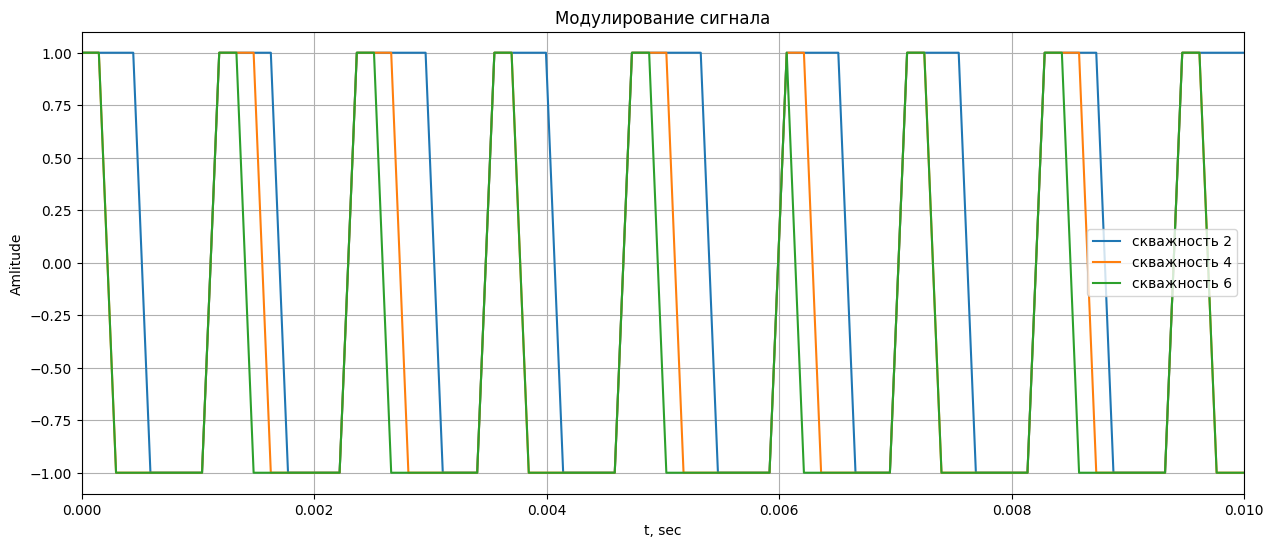

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, mod_sig_2, label='скважность 2')
plt.plot(t, mod_sig_4, label='скважность 4')
plt.plot(t, mod_sig_6, label='скважность 6')
plt.title("Модулирование сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, 0.01, -1.1, 1.1])
plt.grid(True)
plt.legend()
plt.show()

Дискретизация сигнала

In [ ]:
def discretization(signal, QUAN_LV, M):
  dis_sig = []
  for tt in signal:
    dis_sig.append(np.floor((tt + M)*QUAN_LV/(2*M)))
  return dis_sig

In [ ]:
y_2 = discretization(mod_sig_2, QUAN_LV, M)
y_4 = discretization(mod_sig_4, QUAN_LV, M)
y_6 = discretization(mod_sig_6, QUAN_LV, M)

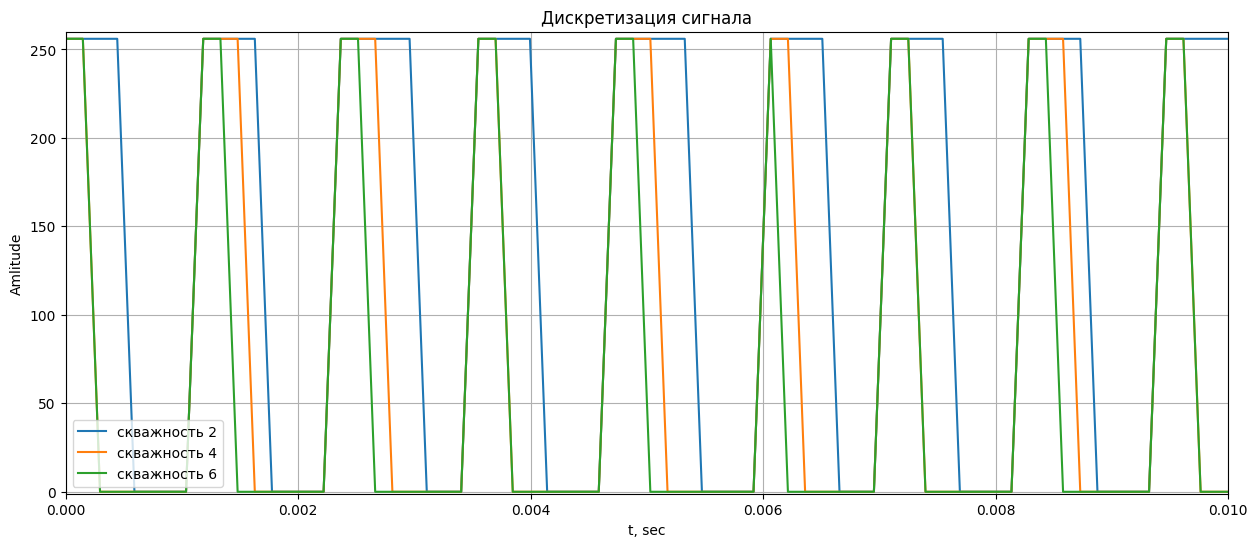

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, y_2, label='скважность 2')
plt.plot(t, y_4, label='скважность 4')
plt.plot(t, y_6, label='скважность 6')
plt.title("Дискретизация сигнала")
plt.xlabel("t, sec")
plt.ylabel("Amlitude")
plt.axis([0, 0.01, -1.1, 260])
plt.grid(True)
plt.legend()
plt.show()

Поиск коэффициентов фильтра Баттерворта

Первый веренос частоты

In [ ]:
def freq_transfer_1(sig, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, n_but=6):
  sin_out = sig * np.sin((np.arange(N) - 1) * 2 * np.pi * FREQ_CAR / SAMPLE_RATE)
  cos_out = sig * np.cos((np.arange(N) - 1) * 2 * np.pi * FREQ_CAR / SAMPLE_RATE)
  b,a = sci.signal.butter(n_but, FREQ_MOD * K_DISC /(2*SAMPLE_RATE))
  sin_out_butt = sci.signal.lfilter(b, a, sin_out)
  cos_out_butt = sci.signal.lfilter(b, a, cos_out)
  detection = np.sqrt(sin_out_butt **2 + cos_out_butt **2)
  return detection

In [ ]:
def freq_transfer_2(sig, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, n_but=6, k_but=1):
  sin_out = sig * np.sin((np.arange(N) - 1) * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)
  cos_out = sig * np.cos((np.arange(N) - 1) * 2 * np.pi * FREQ_MOD / SAMPLE_RATE)

  b,a = sci.signal.butter(n_but, FREQ_MOD * K_DISC /(2*8*SAMPLE_RATE))
  sin_out_butt = sci.signal.lfilter(b, a, sin_out)
  cos_out_butt = sci.signal.lfilter(b, a, cos_out)
  detection = np.sqrt(sin_out_butt **2 + cos_out_butt **2)
  return detection

In [ ]:
detection_2 = freq_transfer_1(y_2, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)
detection_4 = freq_transfer_1(y_4, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)
detection_6 = freq_transfer_1(y_6, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE)

cnt = len(t) / 4;
mid2 = sum(detection_2[int(cnt):2*int(cnt)])
mid4 = sum(detection_4[int(cnt):2*int(cnt)])
mid6 = sum(detection_6[int(cnt):2*int(cnt)])


mid2 = mid2 / cnt * 0.708
mid4 = mid4 / cnt * 0.708
mid6 = mid6 / cnt * 0.708

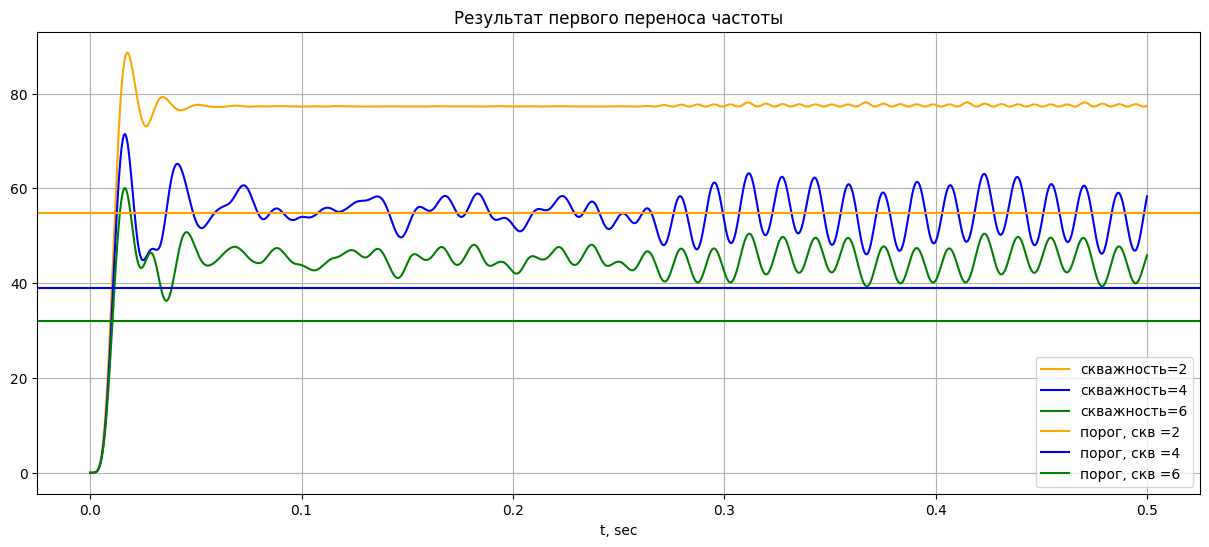

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection_2, label='скважность=2', color='orange')
plt.plot(t, detection_4, label='скважность=4', color='blue')
plt.plot(t, detection_6, label='скважность=6', color='green')
plt.axhline(y=mid2, label='порог, скв =2', color='orange')
plt.axhline(y=mid4, label='порог, скв =4', color='blue')
plt.axhline(y=mid6, label='порог, скв =6', color='green')
plt.title("Результат первого переноса частоты")
plt.xlabel("t, sec")
plt.grid(True)
plt.legend()
plt.show()

Второй перенос частоты

In [ ]:
detection_2_2 = freq_transfer_2(detection_2, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)
detection_4_2 = freq_transfer_2(detection_4, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)
detection_6_2 = freq_transfer_2(detection_6, FREQ_CAR, FREQ_MOD, K_DISC, SAMPLE_RATE, k_but=8)

cnt = len(t) / 4;
mid2 = sum(detection_2_2[int(cnt):2*int(cnt)])
mid4 = sum(detection_4_2[int(cnt):2*int(cnt)])
mid6 = sum(detection_6_2[int(cnt):2*int(cnt)])


mid2 = mid2 / cnt * 0.708
mid4 = mid4 / cnt * 0.708
mid6 = mid6 / cnt * 0.708

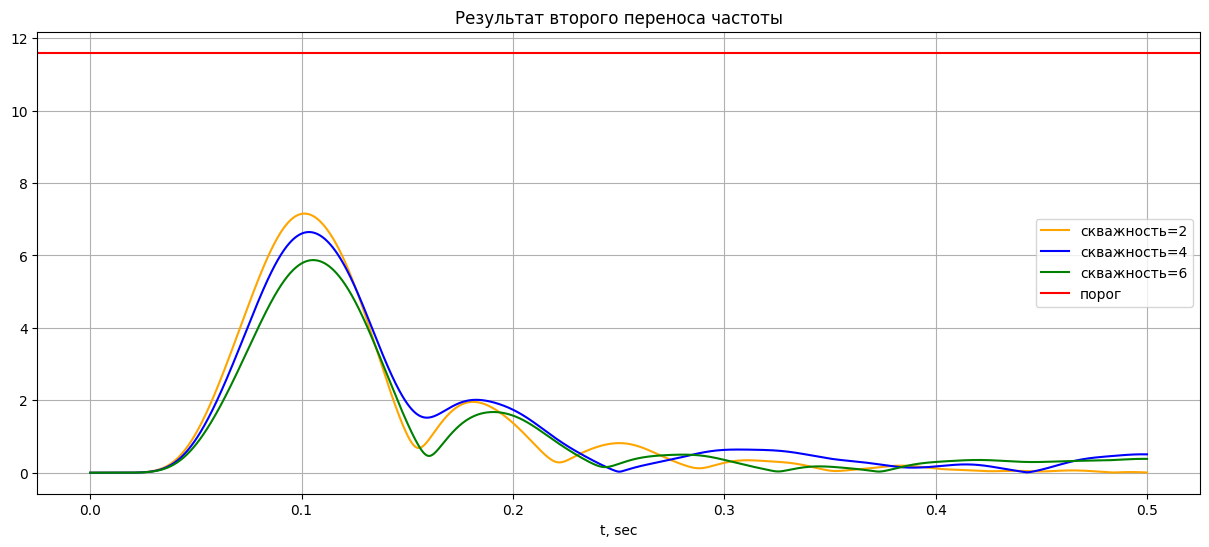

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(t, detection_2_2, label='скважность=2', color='orange')
plt.plot(t, detection_4_2, label='скважность=4', color='blue')
plt.plot(t, detection_6_2, label='скважность=6', color='green')
#plt.axhline(y=mid_2_2, label='порог, скв =2', color='orange')
#plt.axhline(y=mid_4_2, label='порог, скв =4', color='blue')
plt.axhline(y=11.600348147723475, label='порог', color='red')
plt.title("Результат второго переноса частоты")
plt.xlabel("t, sec")
#plt.axis([0, 0.5, 0, 0.003])
plt.grid(True)
plt.legend()
plt.show()

Определение наличия сигнала

In [ ]:
def det_sig(lbound, signal):
  res = []
  for i in range(N):
    tt = signal[i]
    if tt <= lbound:
      res.append(0)
    else:
      res.append(1)
  return res

In [ ]:
det_2 = det_sig(signal=detection_2, lbound=11.600348147723475)
det_4 = det_sig(signal=detection_4, lbound=11.600348147723475)
det_6 = det_sig(signal=detection_6, lbound=11.600348147723475)

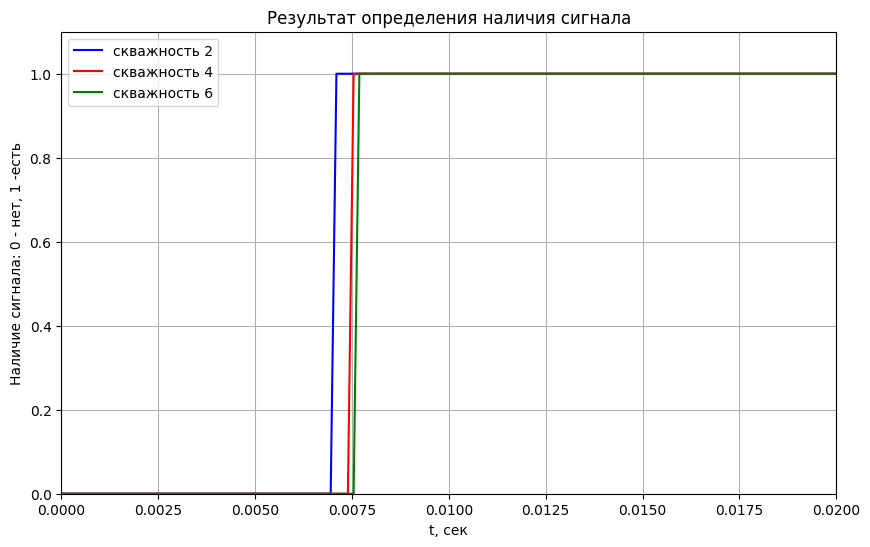

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, det_2, color='blue', label='скважность 2')
plt.plot(t, det_4, color='red', label='скважность 4')
plt.plot(t, det_6, color='green', label='скважность 6')
plt.title("Результат определения наличия сигнала")
plt.xlabel("t, сек")
plt.ylabel("Наличие сигнала: 0 - нет, 1 -есть")
plt.grid(True)
plt.axis([0, 0.02, 0, 1.1])
plt.legend()
plt.show()

Определение задаржки

In [ ]:
k = 1
while det_2[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while det_4[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

k = 1
while det_6[k] == 0:
  k = k + 1
print("Задержка составляет: ", t[k])

Задержка составляет:  0.007100591715976332
Задержка составляет:  0.007544378698224852
Задержка составляет:  0.007692307692307693


Изменения исходного сигнала

In [ ]:
FREQ_MOD_2 = FREQ_CAR + FREQ_MOD * 3
PHASE_MOD_2 = 0
signal_2 = mod_sig_2 + 0.5 * np.sin(2 * np.pi * FREQ_MOD_2 * t + PHASE_MOD_2)

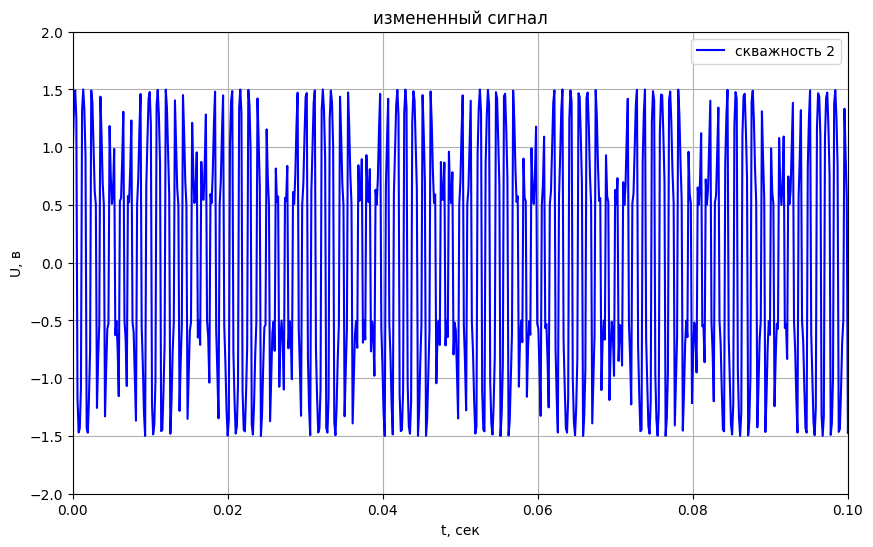

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, signal_2, color='blue', label='скважность 2')
plt.title("измененный сигнал")
plt.xlabel("t, сек")
plt.ylabel("U, в")
plt.axis([0, 0.1, -2, 2])
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from numpy.fft import fft
fftL = 2 ** math.ceil(math.log2(abs(N)))
Y = abs(fft(mod_sig_2, fftL))
Y_magnitude = np.abs(Y[:fftL // 2])
F = np.arange(0, SAMPLE_RATE/2-1/fftL, SAMPLE_RATE/fftL)
Y_magnitude = 2 * Y_magnitude / N
#F = np.linspace(0, SAMPLE_RATE/2, fftL // 2)

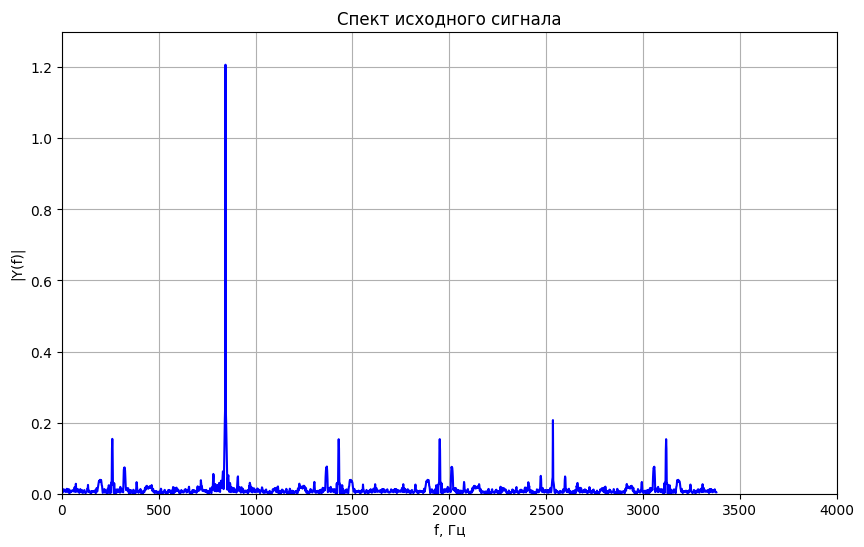

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(F, Y_magnitude, color='blue')
plt.title("Спект исходного сигнала")
plt.xlabel("f, Гц")
plt.ylabel("|Y(f)|")
plt.grid(True)
plt.axis([0, 4000, 0, 1.3])
plt.show()

In [ ]:
from numpy.fft import fft
fftL = 2 ** math.ceil(math.log2(abs(N)))
Y_2 = abs(fft(signal_2, fftL))
Y_magnitude_2 = np.abs(Y[:fftL // 2])
F_2 = np.arange(0, SAMPLE_RATE/2-1/fftL, SAMPLE_RATE/fftL)
Y_magnitude_2 = 2 * Y_magnitude_2 / N

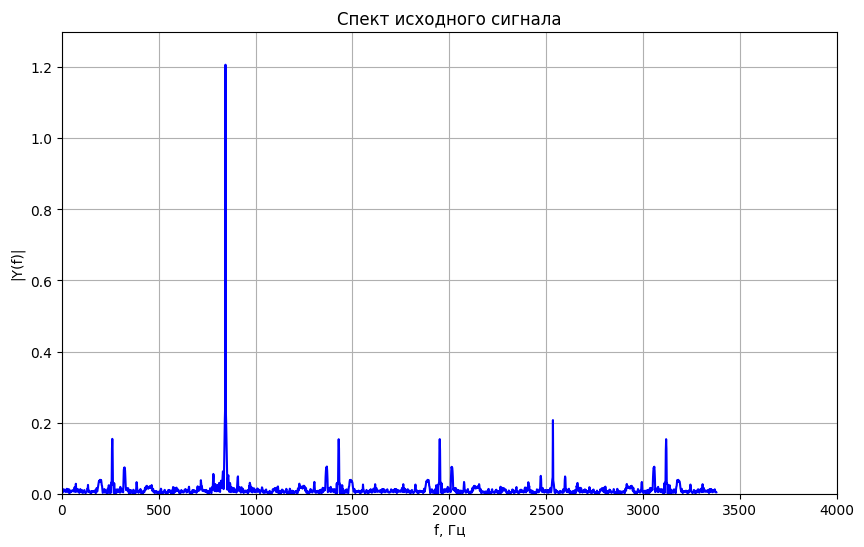

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(F_2, Y_magnitude_2, color='blue')
plt.title("Спект исходного сигнала")
plt.xlabel("f, Гц")
plt.ylabel("|Y(f)|")
plt.grid(True)
plt.axis([0, 4000, 0, 1.3])
plt.show()